Analyze results of optimize_tkg.py

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import json
import os

from optimize_tkg import prepare_target_metrics

# Load optimization results

In [ ]:
df_summary.

In [5]:
df_summary.columns

Index(['trial', 'score', 'n_ents', 'n_rels', 'n_tws', 'n_quads',
       'n_unique_triples', 'avg_degree', 'deg_p25', 'deg_p75',
       'pat_distr_ents', 'pat_distr_rels', 'n_1_hop', 'n_2_hop', 'n_3_hop',
       'rnd_avg_density', 'p_skip_consequence', 'use_force_distr', 'p_force',
       'n_force', 'force_binom_n', 'force_binom_p'],
      dtype='object')

In [21]:
data_dir = './opt_runs_icews14'
trials = os.listdir(data_dir)

summary = {
    'trial_id': [],
    'score': [],
}
for trial in trials:
    if not trial.startswith('trial'):
        continue
    summary['trial_id'].append(int(trial.split('_')[1]))
    trial_dir = os.path.join(data_dir, trial)

    with open(os.path.join(trial_dir, 'score.txt'), 'r') as f:
        score = float(f.readline().strip())
    summary['score'].append(score)

df_summary = pd.DataFrame(summary)
print(df_summary.shape)
df_summary[:3]

(50, 2)


,trial_id,score
0,0,107.185229
1,1,21.949951
2,2,17.934697


<Axes: xlabel='trial_id'>

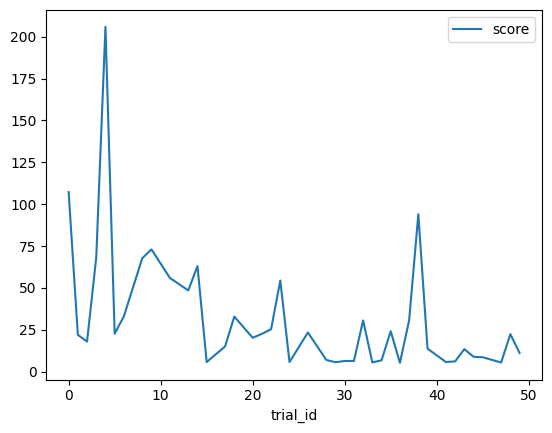

In [17]:
df_summary[df_summary['score'] <= 1e6].plot('trial_id', 'score')

In [23]:
df_summary.sort_values(['score'], ascending=True)[:5]

,trial_id,score
36,36,5.269440
47,47,5.433333
33,33,5.506387
29,29,5.591786
15,15,5.692605


# Compare descriptive statistics of best run and real benchmark dataset

In [37]:
dir_real = '/nas/ckgfs/users/eboxer/TKG-Forecasting-Evaluation/data/ICEWS14'

trial_ids = df_summary.sort_values(['score'], ascending=True)[:5]['trial_id'].tolist()
scores = df_summary.sort_values(['score'], ascending=True)[:5]['score'].tolist()
dirs_synt = []
for trial_id in df_summary.sort_values(['score'], ascending=True)[:5]['trial_id']:
    dirs_synt.append(f'/nas/ckgfs/users/eboxer/synthetic_tkg_patterns/opt_runs_icews14/trial_{trial_id}')
dirs_synt

['/nas/ckgfs/users/eboxer/synthetic_tkg_patterns/opt_runs_icews14/trial_36',
 '/nas/ckgfs/users/eboxer/synthetic_tkg_patterns/opt_runs_icews14/trial_47',
 '/nas/ckgfs/users/eboxer/synthetic_tkg_patterns/opt_runs_icews14/trial_33',
 '/nas/ckgfs/users/eboxer/synthetic_tkg_patterns/opt_runs_icews14/trial_29',
 '/nas/ckgfs/users/eboxer/synthetic_tkg_patterns/opt_runs_icews14/trial_15']

In [27]:
metrics_real = prepare_target_metrics(dir_real)
metrics_real

{'n_ents': 7128,
 'n_rels': 230,
 'n_tws': 365,
 'n_quads': 90730,
 'n_unique_triples': 50295,
 'avg_degree': 25.457351290684624,
 'deg_p25': 1.0,
 'deg_p75': 10.0}

In [38]:
metrics_synt = []
for dir_synt in dirs_synt:
    metrics_synt.append(prepare_target_metrics(os.path.join(dir_synt, 'run_0')))
len(metrics_synt)

5

In [ ]:
params = []
for dir_synt in dirs_synt:
    with open(os.path.join(dir_synt, 'trial_params.json'), 'r') as f:
        params.append(json.load(f))
len(params)

5

In [45]:
pd.set_option('display.max_columns', 50)

In [46]:
df_metrics = pd.DataFrame({
    'trial_id': ['real'] + trial_ids,
    'score': [None] + scores,
    'metrics': [metrics_real] + metrics_synt,
    'params': [{}] + params
})
df_metrics = df_metrics.drop(columns=['metrics', 'params']).join(
    pd.json_normalize(df_metrics['metrics'])
).join(
    pd.json_normalize(df_metrics['params']), rsuffix='_params'
)
print(df_metrics.shape)
df_metrics

(6, 29)


,trial_id,score,n_ents,n_rels,n_tws,n_quads,n_unique_triples,avg_degree,deg_p25,deg_p75,seed_base,n_ents_params,n_rels_params,n_tws_params,_pat_distr_ents_choice,_pat_distr_rels_choice,n_1_hop,n_2_hop,n_3_hop,require_unique_triples,prohibit_selfconnections,prohibit_new_consequence_relations,require_sequential_rule,use_density_dist,rnd_avg_density,p_skip_consequence,use_force_distr,p_force,n_force
0,real,NaN,7128,230,365,90730,50295,25.457351,1.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,36,5.269440,6186,202,365,27180,27144,8.787585,4.0,12.0,0.0,7128.0,230.0,365.0,"gamma(2,2)",uniform,121.0,151.0,14.0,True,False,False,True,False,0.0,0.0,False,0.05,2.0
2,47,5.433333,4083,154,365,27877,24174,13.655156,3.0,20.0,0.0,7128.0,230.0,365.0,empirical,"gamma(3,1)",103.0,2.0,74.0,False,True,False,True,False,0.0,0.0,False,0.05,3.0
3,33,5.506387,6338,152,365,30284,26878,9.556327,4.0,13.0,0.0,7128.0,230.0,365.0,"gamma(2,2)","gamma(1,2)",88.0,171.0,36.0,False,True,False,True,False,0.0,0.0,False,0.05,2.0
4,29,5.591786,5098,221,365,41366,37155,16.228325,4.0,21.0,0.0,7128.0,230.0,365.0,"gamma(0.5,1.0)",uniform,121.0,186.0,84.0,False,True,False,True,False,0.0,0.0,False,0.05,2.0
5,15,5.692605,4987,213,365,35987,31088,14.432324,4.0,19.0,0.0,7128.0,230.0,365.0,"gamma(0.5,1.0)",uniform,149.0,196.0,32.0,False,True,False,True,False,0.0,0.0,False,0.10,1.0


Prefer trial 29